In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.datasets import make_blobs

# Softmax
### used in both Softmax Regression and in Neural Networks when solving `Multiclass Classification problems`
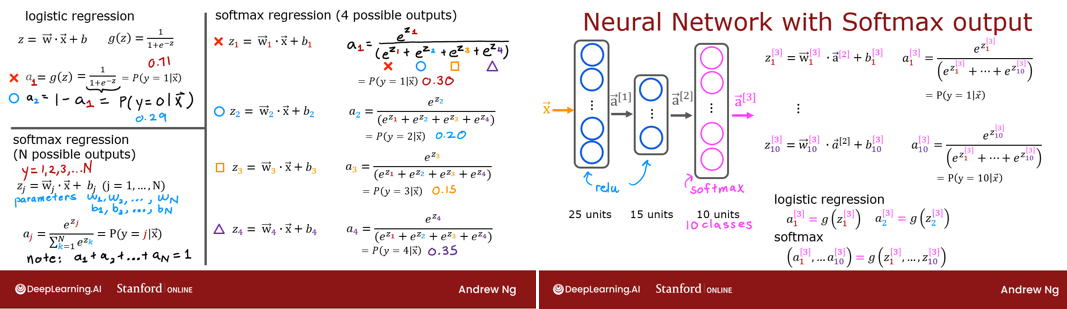


## Softmax Function
### In both softmax regression and neural networks with Softmax outputs, N outputs are generated and one output is selected as the predicted category. In both cases a vector $\mathbf{z}$ is generated by a linear function which is applied to a softmax function. The softmax function converts $\mathbf{z}$  into a probability distribution as described below. After applying softmax, each output will be between 0 and 1 and the outputs will add to 1, so that they can be interpreted as probabilities. The larger inputs  will correspond to larger output probabilities.
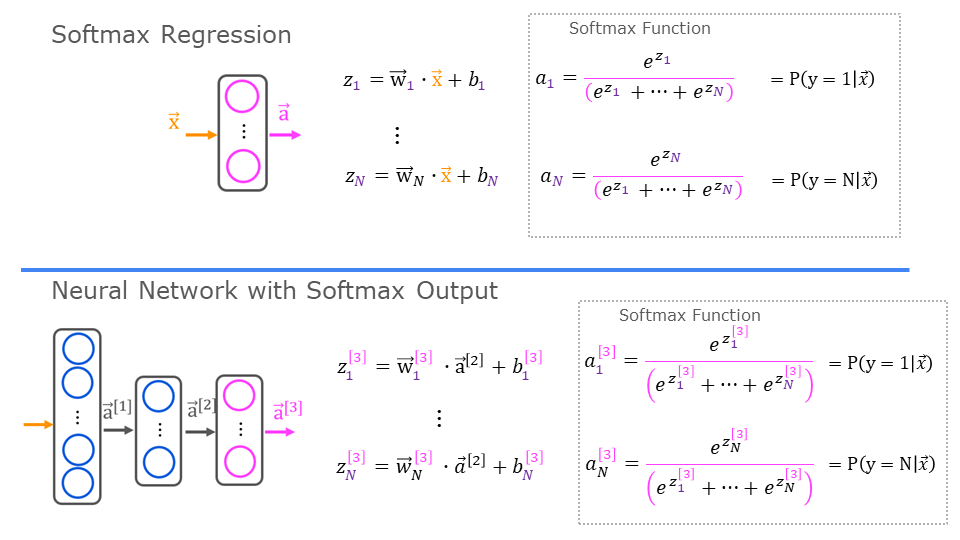


---
The softmax function can be written:
$$a_j = \frac{e^{z_j}}{ \sum_{k=1}^{N}{e^{z_k} }} \tag{1}$$
The output $\mathbf{a}$ is a vector of length N, so for softmax regression, you could also write:
\begin{align}
\mathbf{a}(x) =
\begin{bmatrix}
P(y = 1 | \mathbf{x}; \mathbf{w},b) \\
\vdots \\
P(y = N | \mathbf{x}; \mathbf{w},b)
\end{bmatrix}
=
\frac{1}{ \sum_{k=1}^{N}{e^{z_k} }}
\begin{bmatrix}
e^{z_1} \\
\vdots \\
e^{z_{N}} \\
\end{bmatrix} \tag{2}
\end{align}


In [21]:
def my_softmax(z):
    z = z - np.max(z,axis=-1,keepdims=True) # Prevents numerical overflow when exponentiating large numbers   
    ez = np.exp(z)
    return ez / np.sum(ez, axis=-1, keepdims=True) # probabilities (sum to 1).

# usage ex

In [39]:
z = np.array([1., 2., 3., 4.])
a = my_softmax(z)
print(f"our softmax = {a}")


atf = tf.nn.softmax(z)
print(f"Tensor flow softmax = {atf}")


our softmax = [0.0320586  0.08714432 0.23688282 0.64391426]
Tensor flow softmax = [0.0320586  0.08714432 0.23688282 0.64391426]


# cost

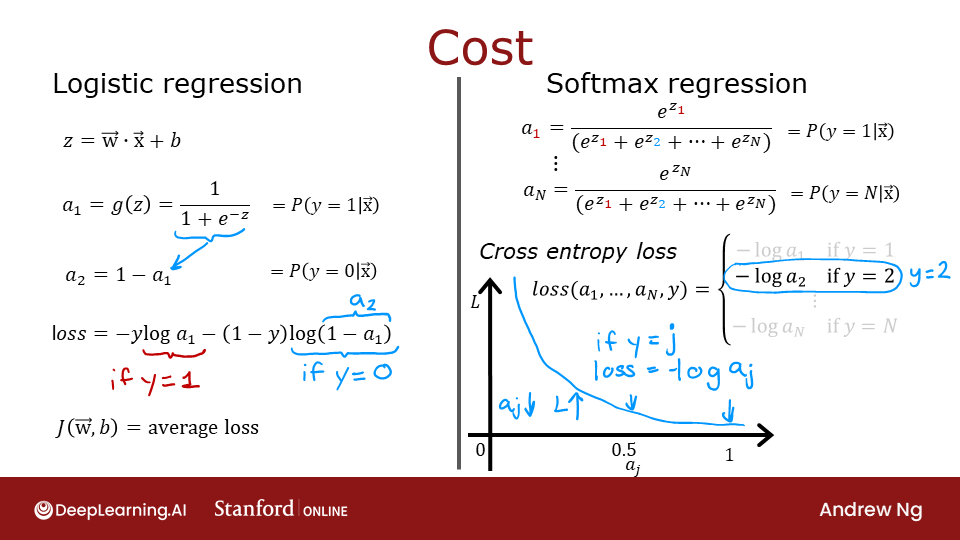

The loss function associated with Softmax, the cross-entropy loss, is:
\begin{equation}
  L(\mathbf{a},y)=\begin{cases}
    -log(a_1), & \text{if $y=1$}.\\
        &\vdots\\
     -log(a_N), & \text{if $y=N$}
  \end{cases} \tag{3}
\end{equation}

Where y is the target category for this example and $\mathbf{a}$ is the output of a softmax function. In particular, the values in $\mathbf{a}$ are probabilities that sum to one.
>**Recall:** In this course, Loss is for one example while Cost covers all examples. 
 
 
Note in (3) above, only the line that corresponds to the target contributes to the loss, other lines are zero. To write the cost equation we need an 'indicator function' that will be 1 when the index matches the target and zero otherwise. 
    $$\mathbf{1}\{y == n\} = =\begin{cases}
    1, & \text{if $y==n$}.\\
    0, & \text{otherwise}.
  \end{cases}$$
Now the cost is:
\begin{align}
J(\mathbf{w},b) = -\frac{1}{m} \left[ \sum_{i=1}^{m} \sum_{j=1}^{N}  1\left\{y^{(i)} == j\right\} \log \frac{e^{z^{(i)}_j}}{\sum_{k=1}^N e^{z^{(i)}_k} }\right] \tag{4}
\end{align}

Where $m$ is the number of examples, $N$ is the number of outputs. This is the average of all the losses.


In [4]:
centers = [[-5, 2], [-2, -2], [1, 2], [5, -2]]

# Generate dataset
X_train, y_train = make_blobs(n_samples=2000, centers=centers, cluster_std=1.0, random_state=30)

In [5]:
X_train.shape,y_train.shape

((2000, 2), (2000,))

# visualize dataset

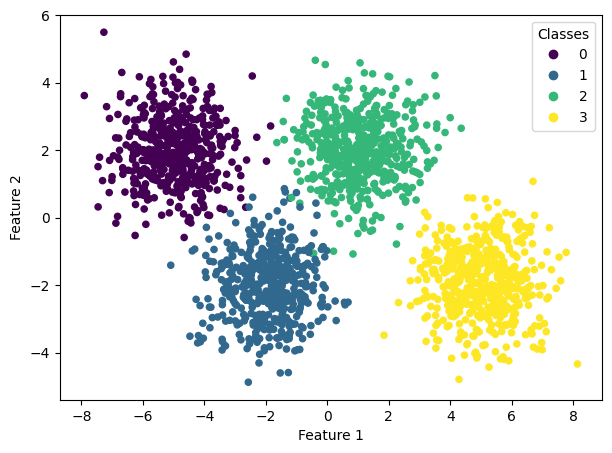

In [6]:
plt.figure(figsize=(7, 5))
scatter = plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='viridis', s=20)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend(*scatter.legend_elements(),title="Classes")
plt.show()

# Model

In [7]:
model = Sequential(
    [
        Dense(25,activation='relu'),
        Dense(15,activation='relu'),
        Dense(4,activation='softmax') # output layer 
    ]
)
model.compile(
    loss = tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer = tf.keras.optimizers.Adam(0.001),
)

model.fit(
    X_train,y_train,
    epochs = 10
)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.0267  
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 980us/step - loss: 0.3613
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 899us/step - loss: 0.1588
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 894us/step - loss: 0.0986
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 784us/step - loss: 0.0740
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0613  
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 935us/step - loss: 0.0536
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 891us/step - loss: 0.0479
Epoch 9/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 773us/step - loss: 0.0439
Epoch 10/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 788us/step - loss: 0.0399


## Because the softmax is integrated into the `output layer`, the output is a `vector of probabilities`.

In [8]:
p_nonpreferred = model.predict(X_train)
print(p_nonpreferred [:2])
print("largest value", np.max(p_nonpreferred), "smallest value", np.min(p_nonpreferred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
[[4.3737749e-03 3.3628126e-03 9.7236550e-01 1.9897865e-02]
 [9.9373382e-01 6.0298271e-03 2.3394929e-04 2.3602693e-06]]
largest value 0.9999981 smallest value 2.8861996e-10


In [9]:
p_nonpreferred.shape

(2000, 4)

In [10]:
for i in range(5):
    print(f"{p_nonpreferred[i]} category -> {np.argmax(p_nonpreferred[i])} ")

[0.00437377 0.00336281 0.9723655  0.01989787] category -> 2 
[9.9373382e-01 6.0298271e-03 2.3394929e-04 2.3602693e-06] category -> 0 
[9.6586776e-01 3.2446254e-02 1.6428544e-03 4.3101056e-05] category -> 0 
[6.5148319e-03 9.8743057e-01 5.5730934e-03 4.8149066e-04] category -> 1 
[4.1226344e-03 2.0721627e-05 9.9574572e-01 1.1091217e-04] category -> 2 


---

## more stable and accurate results can be obtained if the softmax and loss are combined during training.   This is enabled by the 'preferred' organization shown here.

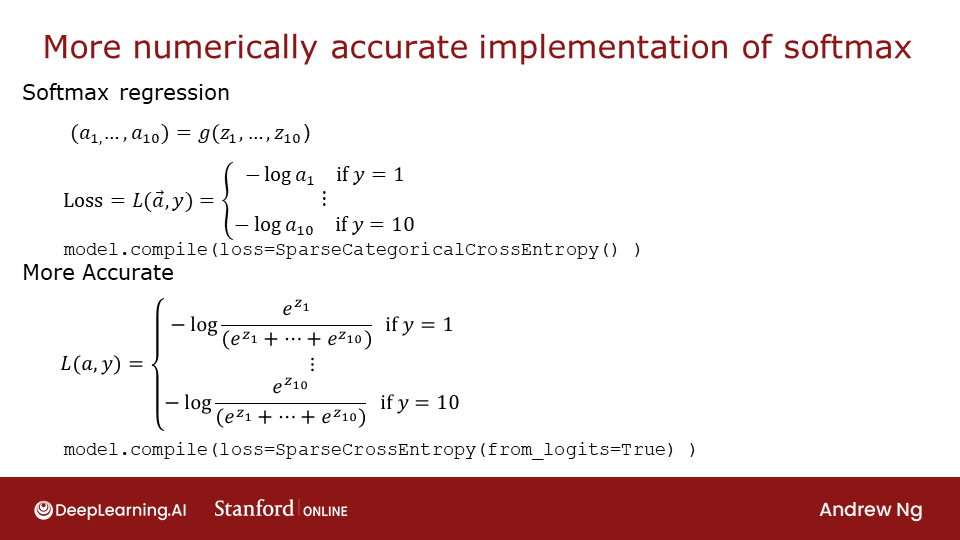

In [11]:
preferred_model = Sequential(
    [
        Dense(25,activation='relu'),
        Dense(15,activation='relu'),
        Dense(4,activation='linear') 
    ]
)

preferred_model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),  
    optimizer=tf.keras.optimizers.Adam(0.001),
)

preferred_model.fit(
    X_train,y_train,
    epochs=10
)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 864us/step - loss: 1.2335 
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 949us/step - loss: 0.5451
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 906us/step - loss: 0.2283
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 904us/step - loss: 0.1190
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 802us/step - loss: 0.0832
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 792us/step - loss: 0.0678
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 881us/step - loss: 0.0585
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0523  
Epoch 9/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 864us/step - loss: 0.0476
Epoch 10/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 859us/step - loss: 0.0435


#### Output Handling
since the output layer is `linear` in the preferred model, the outputs are `not probabilities`, but can range from `large negative numbers to large positive numbers` 

In [12]:
p_preferred = preferred_model.predict(X_train) 

print(f"two example output vectors:\n {p_preferred[:2]}")

print("largest value", np.max(p_preferred), "smallest value", np.min(p_preferred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 907us/step
two example output vectors:
 [[-3.3379438  -3.4774442   3.6321585  -0.56001455]
 [ 5.8287973   0.48487243 -0.28213966 -3.2106557 ]]
largest value 12.78422 smallest value -11.267106


- `p_preferred` raw model outputs before softmax — can be large negative numbers to large positive numbers
- `p`  probabilities

In [14]:
p = my_softmax(p_preferred) # shape (m,n_classes)

In [15]:
print(f"two ex {p[:2]}")

print(f"Largest value = {np.max(p)}\nSmallest value = {np.min(p)}")

two ex [[9.2396932e-04 8.0366147e-04 9.8340976e-01 1.4862672e-02]
 [9.9293607e-01 4.7433386e-03 2.2027998e-03 1.1779763e-04]]
Largest value = 0.9999986886978149
Smallest value = 3.899189027212202e-10


In [16]:
for i in range(5):
    print(f"{p_preferred[i]} -> category: {np.argmax(p_preferred[i])}")

[-3.3379438  -3.4774442   3.6321585  -0.56001455] -> category: 2
[ 5.8287973   0.48487243 -0.28213966 -3.2106557 ] -> category: 0
[ 4.2418094  0.6167318 -0.3254764 -2.6988378] -> category: 0
[-1.6322511  3.1853669 -1.5535369 -2.693771 ] -> category: 1
[ 0.7440352 -4.281582   5.872792  -3.5404258] -> category: 2


In [17]:
for i in range(5):
    print(f"{p[i]} -> category: {np.argmax(p[i])}")

[9.2396932e-04 8.0366147e-04 9.8340976e-01 1.4862672e-02] -> category: 2
[9.9293607e-01 4.7433386e-03 2.2027998e-03 1.1779763e-04] -> category: 0
[9.6339035e-01 2.5671495e-02 1.0005883e-02 9.3221810e-04] -> category: 0
[0.00793034 0.98074657 0.0085798  0.00274334] -> category: 1
[5.8883303e-03 3.8671817e-05 9.9399179e-01 8.1147358e-05] -> category: 2


## SparseCategorialCrossentropy or CategoricalCrossEntropy
Tensorflow has two potential formats for target values and the selection of the loss defines which is expected.
- SparseCategorialCrossentropy: expects the target to be an integer corresponding to the index. For example, if there are 10 potential target values, y would be between 0 and 9. 
- CategoricalCrossEntropy: Expects the target value of an example to be one-hot encoded where the value at the target index is 1 while the other N-1 entries are zero. An example with 10 potential target values, where the target is 2 would be [0,0,1,0,0,0,0,0,0,0].
